# Análise SINASC — Nascidos Vivos (DataSUS)

Microdados de Declarações de Nascido Vivo (DN) por UF.

**Download:** execute antes no terminal:

```bash
python scripts/download_sinasc.py --uf SC --years 2017-2024
```

- **2017–2022:** PySUS → `data/parquet/`
- **2023–2024:** [Portal DATASUS](https://datasus.saude.gov.br/transferencia-de-arquivos/) → `data/raw/` (.dbc)

In [2]:
import sys
from pathlib import Path

import pandas as pd

ROOT = Path(".").resolve()
sys.path.insert(0, str(ROOT / "scripts"))

from load_sinasc import load_year

UF = "SC"
ANO = 2024
RAW_DIR = ROOT / "data" / "raw"
PARQUET_DIR = ROOT / "data" / "parquet"

In [3]:
df = load_year(UF, ANO, RAW_DIR, PARQUET_DIR)

print(f"Registros: {df.shape[0]:,}")
print(f"Variáveis: {df.shape[1]}")
df.head()

Registros: 93,787
Variáveis: 61


,ORIGEM,CODESTAB,CODMUNNASC,LOCNASC,IDADEMAE,ESTCIVMAE,ESCMAE,CODOCUPMAE,QTDFILVIVO,QTDFILMORT,...,TPDOCRESP,DTDECLARAC,ESCMAEAGR1,STDNEPIDEM,STDNNOVA,CODPAISRES,TPROBSON,PARIDADE,KOTELCHUCK,CONTADOR
0,1,2317990,150616,1,24,2,4,999992,01,00,...,3,25032024,06,0,1,1,05,1,5,103406
1,1,7029527,221100,1,31,5,5,999991,02,00,...,5,15042024,07,1,1,1,05,1,4,189567
2,1,3649563,240810,1,30,2,5,252105,00,01,...,5,20052024,08,1,1,1,03,1,3,261920
3,1,6679528,251250,1,25,2,4,622020,00,00,...,5,17062024,06,1,1,1,02,0,5,293624
4,1,0806285,270240,1,24,5,4,752430,00,00,...,3,20062024,06,1,1,1,01,0,5,359626


In [4]:
print(f"Estrutura: {df.shape}")
print(f"\nColunas ({len(df.columns)}):")
print(list(df.columns))

Estrutura: (93787, 61)

Colunas (61):
['ORIGEM', 'CODESTAB', 'CODMUNNASC', 'LOCNASC', 'IDADEMAE', 'ESTCIVMAE', 'ESCMAE', 'CODOCUPMAE', 'QTDFILVIVO', 'QTDFILMORT', 'CODMUNRES', 'GESTACAO', 'GRAVIDEZ', 'PARTO', 'CONSULTAS', 'DTNASC', 'HORANASC', 'SEXO', 'APGAR1', 'APGAR5', 'RACACOR', 'PESO', 'IDANOMAL', 'DTCADASTRO', 'CODANOMAL', 'NUMEROLOTE', 'VERSAOSIST', 'DTRECEBIM', 'DIFDATA', 'DTRECORIGA', 'NATURALMAE', 'CODMUNNATU', 'CODUFNATU', 'ESCMAE2010', 'SERIESCMAE', 'DTNASCMAE', 'RACACORMAE', 'QTDGESTANT', 'QTDPARTNOR', 'QTDPARTCES', 'IDADEPAI', 'DTULTMENST', 'SEMAGESTAC', 'TPMETESTIM', 'CONSPRENAT', 'MESPRENAT', 'TPAPRESENT', 'STTRABPART', 'STCESPARTO', 'TPNASCASSI', 'TPFUNCRESP', 'TPDOCRESP', 'DTDECLARAC', 'ESCMAEAGR1', 'STDNEPIDEM', 'STDNNOVA', 'CODPAISRES', 'TPROBSON', 'PARIDADE', 'KOTELCHUCK', 'CONTADOR']


In [5]:
# Carregar vários anos e concatenar (opcional)
anos = range(2017, 2025)
frames = []

for ano in anos:
    try:
        dados = load_year(UF, ano, RAW_DIR, PARQUET_DIR)
        dados["ANO_REF"] = ano
        frames.append(dados)
        print(f"{ano}: {len(dados):,} registros")
    except FileNotFoundError as exc:
        print(f"{ano}: não encontrado — {exc}")

if frames:
    df_todos = pd.concat(frames, ignore_index=True)
    print(f"\nTotal combinado: {len(df_todos):,} registros")

2017: 98,335 registros
2018: 99,609 registros
2019: 98,032 registros
2020: 97,916 registros
2021: 96,499 registros
2022: 98,202 registros
2023: 96,802 registros
2024: 93,787 registros

Total combinado: 779,182 registros


## Lages (SC) — nascidos vivos

Filtro pelo município de nascimento (`CODMUNNASC` = `420930`, código IBGE de Lages/SC) e mães com idade entre **10 e 19 anos**.

In [7]:
COD_MUNICIPIO_LAGES = "420930"

df_lages = df_todos[df_todos["CODMUNNASC"].astype(str).str.strip() == COD_MUNICIPIO_LAGES].copy()
df_lages["IDADEMAE_NUM"] = pd.to_numeric(df_lages["IDADEMAE"], errors="coerce")

print(f"Lages — registros: {len(df_lages):,}")
print(f"Anos: {sorted(df_lages['ANO_REF'].unique())}")
df_lages.head()

Lages — registros: 27,581
Anos: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


,contador,ORIGEM,CODESTAB,CODMUNNASC,LOCNASC,IDADEMAE,ESTCIVMAE,ESCMAE,CODOCUPMAE,QTDFILVIVO,...,ESCMAEAGR1,STDNEPIDEM,STDNNOVA,CODPAISRES,TPROBSON,PARIDADE,KOTELCHUCK,ANO_REF,CONTADOR,IDADEMAE_NUM
35214,35215,1,2504332,420930,1,18,5,4,999992,00,...,06,0,1,,10,0,3,2017,NaN,18
35215,35216,1,2504332,420930,1,20,1,4,999992,01,...,04,0,1,,03,1,4,2017,NaN,20
35216,35217,1,2504332,420930,1,37,1,4,322205,00,...,05,0,1,,02,0,5,2017,NaN,37
35217,35218,1,2504332,420930,1,21,1,3,512115,01,...,03,0,1,,10,1,5,2017,NaN,21
35218,35219,1,2504332,420930,1,34,2,5,251510,01,...,08,0,1,,03,1,3,2017,NaN,34


In [8]:
resumo_lages = (
    df_lages.groupby("ANO_REF", as_index=False)
    .agg(
        total_nascimentos=("ANO_REF", "size"),
        maes_10_a_19=("IDADEMAE_NUM", lambda s: ((s >= 10) & (s <= 19)).sum()),
    )
    .sort_values("ANO_REF")
)

resumo_lages["pct_maes_10_a_19"] = (
    resumo_lages["maes_10_a_19"] / resumo_lages["total_nascimentos"] * 100
).round(1)

resumo_lages

,ANO_REF,total_nascimentos,maes_19_ou_menos,pct_maes_19_ou_menos
0,2017,3870,658,17.0
1,2018,3670,620,16.9
2,2019,3517,537,15.3
3,2020,3526,490,13.9
4,2021,3333,463,13.9
5,2022,3325,406,12.2
6,2023,3365,373,11.1
7,2024,2975,294,9.9


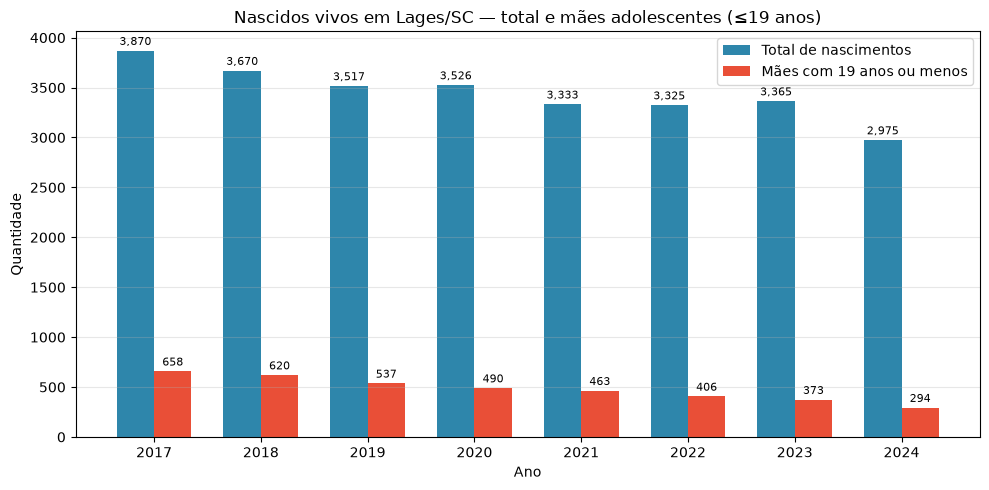

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

anos = resumo_lages["ANO_REF"]
largura = 0.35
x = range(len(anos))

ax.bar([i - largura / 2 for i in x], resumo_lages["total_nascimentos"], width=largura, label="Total de nascimentos", color="#2E86AB")
ax.bar([i + largura / 2 for i in x], resumo_lages["maes_10_a_19"], width=largura, label="Mães de 10 a 19 anos", color="#E94F37")

ax.set_xticks(list(x))
ax.set_xticklabels(anos)
ax.set_xlabel("Ano")
ax.set_ylabel("Quantidade")
ax.set_title("Nascidos vivos em Lages/SC — total e mães de 10 a 19 anos")
ax.legend()
ax.grid(axis="y", alpha=0.3)

for idx, row in enumerate(resumo_lages.itertuples()):
    ax.text(idx - largura / 2, row.total_nascimentos + 30, f"{row.total_nascimentos:,}", ha="center", va="bottom", fontsize=8)
    ax.text(idx + largura / 2, row.maes_10_a_19 + 30, f"{row.maes_10_a_19:,}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
### Detalhamento por idade (10–19 anos)

Quantidade de nascimentos por idade da mãe em cada ano — para visualizar a queda em cada faixa etária.

In [ ]:
maes_adolescentes = df_lages[df_lages["IDADEMAE_NUM"].between(10, 19)].copy()

idade_por_ano = (
    maes_adolescentes.groupby(["ANO_REF", "IDADEMAE_NUM"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=range(10, 20), fill_value=0)
    .astype(int)
    .sort_index()
)

idade_por_ano

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mapa de calor: cada ano × idade (10–19)
ax0 = axes[0]
dados = idade_por_ano.values
im = ax0.imshow(dados, aspect="auto", cmap="YlOrRd")
ax0.set_xticks(range(10))
ax0.set_xticklabels(range(10, 20))
ax0.set_yticks(range(len(idade_por_ano.index)))
ax0.set_yticklabels(idade_por_ano.index)
ax0.set_xlabel("Idade da mãe (anos)")
ax0.set_ylabel("Ano")
ax0.set_title("Nascimentos por idade e ano")

for i, ano in enumerate(idade_por_ano.index):
    for j, valor in enumerate(idade_por_ano.loc[ano]):
        if valor > 0:
            cor = "white" if valor > dados.max() * 0.45 else "black"
            ax0.text(j, i, valor, ha="center", va="center", fontsize=7, color=cor)

fig.colorbar(im, ax=ax0, label="Nascimentos")

# Linhas: evolução anual em cada idade
ax1 = axes[1]
cmap = plt.cm.tab10
for idx, idade in enumerate(range(10, 20)):
    ax1.plot(
        idade_por_ano.index,
        idade_por_ano[idade],
        marker="o",
        linewidth=1.8,
        label=f"{idade} anos",
        color=cmap(idx % 10),
    )

ax1.set_xlabel("Ano")
ax1.set_ylabel("Nascimentos")
ax1.set_title("Queda ao longo dos anos por idade da mãe")
ax1.legend(title="Idade", ncol=2, fontsize=7, loc="upper right")
ax1.grid(alpha=0.3)

plt.tight_layout()
plt.show()